# This notebook tests the functionality of the memory retrieval

In [1]:
from student.agent.memory import Memory, MemoryNode

In [2]:
from collections import OrderedDict
import pandas as pd

TAU = 0.4
SENS = TAU

def score_node(node, query):
    """Return a dict with both methods' scores and a matching-aware tuple."""
    basic_score = node.get_score(query, sensitivity=SENS)
    m_info = node.get_score_matching(query, tau=TAU, return_tuple=True)
    # tolerate variants in return payload
    if isinstance(m_info, dict):
        score_scalar = m_info.get('score_scalar', None)
        score_tuple  = m_info.get('score_tuple', None)
        matches      = m_info.get('matches', [])
    else:
        # fallback if your method returns the tuple directly
        score_scalar, score_tuple, matches = None, m_info, []
    m, mean_w, max_w = (0, 0.0, 0.0) if not score_tuple else score_tuple
    return {
        "Basic": float(basic_score),
        "m": int(m),
        "MeanW": float(mean_w),
        "MaxW": float(max_w),
        "Matches": matches,
        "Scalar": score_scalar
    }

def rank_old(df):
    """Higher Basic score first; tie-break by Node label to stabilize."""
    return df.sort_values(["Basic", "Node"], ascending=[False, True])

def rank_matching(df):
    """
    Lexicographic ranking for the matching variant:
    1) more pairs (m) first
    2) then higher MeanW
    3) then higher MaxW
    4) then Node label to stabilize.
    """
    return df.sort_values(["m", "MeanW", "MaxW", "Node"],
                          ascending=[False, False, False, True])

# ---------------------------------------------------------------------------
# Pack 1: your original fruit/vehicle nodes (concrete semantics)
# ---------------------------------------------------------------------------
def make_pack_fruit_vehicle():
    nodes = [
        MemoryNode(content="Node about apples and fruit",    keys=["apple", "fruit", "red"]),
        MemoryNode(content="Node about bananas and fruit",   keys=["banana", "fruit", "yellow"]),
        MemoryNode(content="Node about cars and vehicles",   keys=["car", "vehicle", "engine"]),
        MemoryNode(content="Node about bicycles and vehicles", keys=["bicycle", "vehicle", "pedal"]),
        MemoryNode(content="Node about strawberries and berries", keys=["strawberry", "berry", "red"]),
    ]
    for n in nodes:
        n.set_embeddings()
    queries = [
        (["fruit"],                   "Q1 single facet: fruit"),
        (["vehicle"],                 "Q2 single facet: vehicle"),
        (["red"],                     "Q3 single facet: red"),
        (["banana", "yellow"],        "Q4 two facets for bananas"),
        (["engine", "car"],           "Q5 two facets for cars"),
        (["berry", "red"],            "Q6 two facets for berry")
    ]
    return nodes, queries

# ---------------------------------------------------------------------------
# Pack 2: synthetic coverage/dilution/duplicates (controlled structure)
# keys use literal tokens, which embed fine; we rely on relational structure.
# ---------------------------------------------------------------------------
def make_pack_structured():
    nodes = [
        # N1: single facet many duplicates
        MemoryNode(content="A-only (duplicates)", keys=["alpha", "alpha", "alpha"]),
        # N2: three-facet coverage
        MemoryNode(content="A+B+C", keys=["alpha", "beta", "gamma"]),
        # N3: two-facet + filler
        MemoryNode(content="A+B+noise", keys=["alpha", "beta", "xeno", "yurt"]),
        # N4: single perfect key
        MemoryNode(content="A only", keys=["alpha"]),
        # N5: balanced two-facet
        MemoryNode(content="A+B", keys=["alpha", "beta"]),
        # N6: heterogeneous many
        MemoryNode(content="A..E", keys=["alpha", "beta", "gamma", "delta", "epsilon"]),
        # N8: one facet + many noise
        MemoryNode(content="A+noise", keys=["alpha", "noise1", "noise2", "noise3", "noise4"]),
        # N9: competing keys for same facet (A1,A2,B)
        MemoryNode(content="A-dup + B", keys=["alpha", "alpha", "beta"]),
        # N10: spread, moderate that should benefit from coverage
        MemoryNode(content="A+C+E", keys=["alpha", "gamma", "epsilon"]),
    ]
    for n in nodes:
        n.set_embeddings()

    queries = [
        (["alpha"],                       "T1 duplicates vs single"),
        (["alpha", "beta"],               "T2 coverage 2 facets (A,B)"),
        (["alpha", "beta", "gamma"],      "T3 coverage 3 facets (A,B,C)"),
        (["alpha", "beta", "gamma", "z"], "T4 extra unmatched facet shouldn't hurt"),
        (["alpha", "beta"],               "T5 dilution: extra noise keys in a node"),
        (["alpha", "alpha2"],             "T6 redundant queries (near-dup of alpha)"),
        (["alpha", "beta"],               "T7 competing keys for same facet"),
        (["alpha", "beta", "gamma", "delta", "epsilon", "phi"], "T9 long sparse"),
        (["zulu"],                        "T10 off-topic (no matches)"),
        (["alpha", "gamma", "epsilon"],   "T11 one strong vs many moderate"),
        (["alpha"],                       "T12 many noise vs compact"),
    ]
    return nodes, queries

# ---------------------------------------------------------------------------
# Expectation checkers (lightweight “rules”) for sanity flags
# These don’t fail the run; they annotate PASS/FLAG to help eyeballing behavior.
# They use node content prefixes to identify nodes in Pack 2.
# ---------------------------------------------------------------------------
def expectation_flag(test_label, ranked_old, ranked_m):
    """
    Return (flag_old, flag_m, note) where flags are "PASS"/"FLAG".
    We only encode rules that should be robust across embeddings.
    """
    def topn(df, n=3):
        return list(df["Node"])[:n]

    # Default: no assertion
    flag_old, flag_m, note = "PASS", "PASS", ""

    # Helper lambdas
    def has(df, prefix):
        return any(x.startswith(prefix) for x in df["Node"])

    def index_of(df, prefix):
        for i, x in enumerate(df["Node"].tolist()):
            if x.startswith(prefix):
                return i
        return None

    # A few robust expectations for Pack 2
    if "T2 coverage 2 facets" in test_label:
        # "A+B" should rank above "A-only (duplicates)" in matching
        i_ab_m = index_of(ranked_m, "A+B")
        i_aaa_m = index_of(ranked_m, "A-only (duplicates)")
        if i_ab_m is not None and i_aaa_m is not None and i_ab_m >= i_aaa_m:
            flag_m, note = "FLAG", "Matching did not promote A+B over A-only duplicates."
    if "T3 coverage 3 facets" in test_label:
        i_abc_m = index_of(ranked_m, "A+B+C")
        i_aaa_m = index_of(ranked_m, "A-only (duplicates)")
        if i_abc_m is not None and i_aaa_m is not None and i_abc_m >= i_aaa_m:
            flag_m, note = "FLAG", "Matching did not place A+B+C above A-only duplicates."
    if "T5 dilution" in test_label:
        # Old score should penalize "A+B+noise" vs "A+B"
        i_noise_old = index_of(ranked_old, "A+B+noise")
        i_ab_old = index_of(ranked_old, "A+B")
        if i_noise_old is not None and i_ab_old is not None and i_noise_old < i_ab_old:
            flag_old, note = "FLAG", "Old score did not penalize dilution as expected."
        # Matching should tie or be close; allow if noise ranks worse or equal.
    if "T12 many noise vs compact" in test_label:
        # Old should prefer compact A only
        i_noise_old = index_of(ranked_old, "A+noise")
        i_a_old = index_of(ranked_old, "A only")
        if i_noise_old is not None and i_a_old is not None and i_noise_old < i_a_old:
            flag_old, note = "FLAG", "Old score did not prefer compact A over A+noise."
        # Matching should be near tie (positions close)
        i_noise_m = index_of(ranked_m, "A+noise")
        i_a_m = index_of(ranked_m, "A only")
        if None not in (i_noise_m, i_a_m) and abs(i_noise_m - i_a_m) > 2:
            flag_m, note = "FLAG", "Matching did not neutralize noise keys as expected."

    return flag_old, flag_m, note


def run_suite(node_packs, tau=TAU, sensitivity=SENS, show_tables=True):
    all_tables = []
    summary_rows = []

    for pack_name, (nodes, queries) in node_packs.items():
        # Prepare a short label for each node (first key or content head)
        node_labels = []
        for n in nodes:
            # Use the first key if available, else first 18 chars of content
            label = (list(n.keys)[0] + "...") if getattr(n, "keys", None) else (n.content[:18] + "...")
            node_labels.append(label)

        for q_terms, q_label in queries:
            rows = []
            for node, node_label in zip(nodes, node_labels):
                res = score_node(node, q_terms)
                rows.append({
                    "Pack": pack_name,
                    "Test": q_label,
                    "Query": "+".join(q_terms),
                    "Node": node_label,
                    "Basic": res["Basic"],
                    "m": res["m"],
                    "MeanW": res["MeanW"],
                    "MaxW": res["MaxW"],
                })
            df = pd.DataFrame(rows)

            ranked_o = rank_old(df)
            ranked_m = rank_matching(df)

            # expectation flags (only meaningful for the structured pack)
            flag_old, flag_m, note = expectation_flag(q_label, ranked_o, ranked_m)

            if show_tables:
                print("\n" + "="*88)
                print(f"[{pack_name}] {q_label}")
                print("Query:", q_terms)
                print("- Old (descending Basic) ----------------")
                print(ranked_o[["Node","Basic","m","MeanW","MaxW"]].to_string(index=False))
                print("- Matching (m -> MeanW -> MaxW) --------")
                print(ranked_m[["Node","m","MeanW","MaxW","Basic"]].to_string(index=False))
                if note:
                    print(f"Rule check: OLD={flag_old}, MATCHING={flag_m}  |  {note}")
                else:
                    print(f"Rule check: OLD={flag_old}, MATCHING={flag_m}")

            all_tables.append(df.assign(Ranking="Raw"))
            summary_rows.append({
                "Pack": pack_name,
                "Test": q_label,
                "Query": "+".join(q_terms),
                "OldTop1": ranked_o.iloc[0]["Node"],
                "MatchTop1": ranked_m.iloc[0]["Node"],
                "Old_vs_Matching": "SAME" if ranked_o.iloc[0]["Node"] == ranked_m.iloc[0]["Node"] else "DIFF",
                "RuleCheck_OLD": flag_old,
                "RuleCheck_MATCH": flag_m,
                "Note": note
            })

    summary = pd.DataFrame(summary_rows)
    if show_tables:
        print("\n" + "="*88)
        print("SUMMARY (Top-1 + Rule flags)")
        print(summary.to_string(index=False))
    return summary

In [3]:
pack1_nodes, pack1_queries = make_pack_fruit_vehicle()
pack2_nodes, pack2_queries = make_pack_structured()

node_packs = OrderedDict({
    "FruitVehicle": (pack1_nodes, pack1_queries),
    "Structured":   (pack2_nodes, pack2_queries),
})

summary = run_suite(node_packs, tau=TAU, sensitivity=SENS, show_tables=False)
summary

,Pack,Test,Query,OldTop1,MatchTop1,Old_vs_Matching,RuleCheck_OLD,RuleCheck_MATCH,Note
0,FruitVehicle,Q1 single facet: fruit,fruit,fruit...,fruit...,SAME,PASS,PASS,
1,FruitVehicle,Q2 single facet: vehicle,vehicle,vehicle...,pedal...,DIFF,PASS,PASS,
2,FruitVehicle,Q3 single facet: red,red,berry...,berry...,SAME,PASS,PASS,
3,FruitVehicle,Q4 two facets for bananas,banana+yellow,fruit...,fruit...,SAME,PASS,PASS,
4,FruitVehicle,Q5 two facets for cars,engine+car,vehicle...,vehicle...,SAME,PASS,PASS,
5,FruitVehicle,Q6 two facets for berry,berry+red,berry...,berry...,SAME,PASS,PASS,
6,Structured,T1 duplicates vs single,alpha,alpha...,alpha...,SAME,PASS,PASS,
7,Structured,"T2 coverage 2 facets (A,B)",alpha+beta,alpha...,alpha...,SAME,PASS,PASS,
8,Structured,"T3 coverage 3 facets (A,B,C)",alpha+beta+gamma,alpha...,delta...,DIFF,PASS,PASS,
9,Structured,T4 extra unmatched facet shouldn't hurt,alpha+beta+gamma+z,alpha...,delta...,DIFF,PASS,PASS,


In [ ]:

long_rows = []
for pack_name, (nodes, queries) in node_packs.items():
    labels = [(list(n.keys)[0] + "...") for n in nodes]
    for q_terms, q_label in queries:
        rows = []
        for node, node_label in zip(nodes, labels):
            res = score_node(node, q_terms)
            rows.append({"Node": node_label, **res})
        df = pd.DataFrame(rows)
        ranked_o = rank_old(df).assign(RankOld=lambda x: range(1, len(x)+1))
        ranked_m = rank_matching(df).assign(RankMatch=lambda x: range(1, len(x)+1))
        merged = pd.merge(ranked_o[["Node","Basic","RankOld"]],
                            ranked_m[["Node","m","MeanW","MaxW","RankMatch"]],
                            on="Node", how="outer")
        merged.insert(0, "Pack", pack_name)
        merged.insert(1, "Test", q_label)
        merged.insert(2, "Query", "+".join(q_terms))
        long_rows.append(merged)
big_table = pd.concat(long_rows, ignore_index=True)
print("\nBIG TABLE (for offline inspection)")
print(big_table.to_string(index=False))


# Timing Analysis of Scoring Methods

In [9]:
import time
import numpy as np

def measure_scoring_times(nodes, queries, n_repeats=10):
    timing_data = []
    
    for query in queries:
        q_terms = query[0]  # Extract query terms from (terms, label) tuple
        
        # Multiple measurements for each node-query pair
        for node in nodes:
            basic_times = []
            matching_times = []
            
            for _ in range(n_repeats):
                # Time basic scoring
                t0 = time.perf_counter()
                basic_score = node.get_score(q_terms, sensitivity=SENS)
                t1 = time.perf_counter()
                basic_times.append(t1 - t0)
                
                # Time matching scoring
                t0 = time.perf_counter()
                matching_score = node.get_score_matching(q_terms, tau=TAU)
                t1 = time.perf_counter()
                matching_times.append(t1 - t0)
            
            # Calculate statistics
            basic_mean = np.mean(basic_times) * 1000  # Convert to milliseconds
            matching_mean = np.mean(matching_times) * 1000
            relative_time = matching_mean / basic_mean if basic_mean > 0 else float('inf')
            
            timing_data.append({
                'Query': '+'.join(q_terms),
                'Node': list(node.keys)[0] + '...',
                'Basic_Time_ms': f"{basic_mean:.3f}",
                'Matching_Time_ms': f"{matching_mean:.3f}",
                'Relative_Time': f"{relative_time:.2f}x"
            })
    
    return pd.DataFrame(timing_data)

# Run timing analysis for both packs
#print("Timing Analysis for Pack 1 (Fruit/Vehicle):")
timing_df_1 = measure_scoring_times(pack1_nodes, pack1_queries)
#display(timing_df_1)

#print("\nTiming Analysis for Pack 2 (Structured):")
timing_df_2 = measure_scoring_times(pack2_nodes, pack2_queries)
#display(timing_df_2)

# Calculate overall statistics
all_timings = pd.concat([timing_df_1, timing_df_2])
basic_times = all_timings['Basic_Time_ms'].astype(float)
matching_times = all_timings['Matching_Time_ms'].astype(float)
relative_times = matching_times / basic_times

print("\nOverall Statistics:")
print(f"Average Basic Time: {basic_times.mean():.3f} ms")
print(f"Average Matching Time: {matching_times.mean():.3f} ms")
print(f"Average Relative Time: {relative_times.mean():.2f}x")
print(f"Median Relative Time: {relative_times.median():.2f}x")


Overall Statistics:
Average Basic Time: 0.035 ms
Average Matching Time: 0.049 ms
Average Relative Time: 1.40x
Median Relative Time: 1.38x


# Scaling Analysis with Increasing Keys/Query Terms

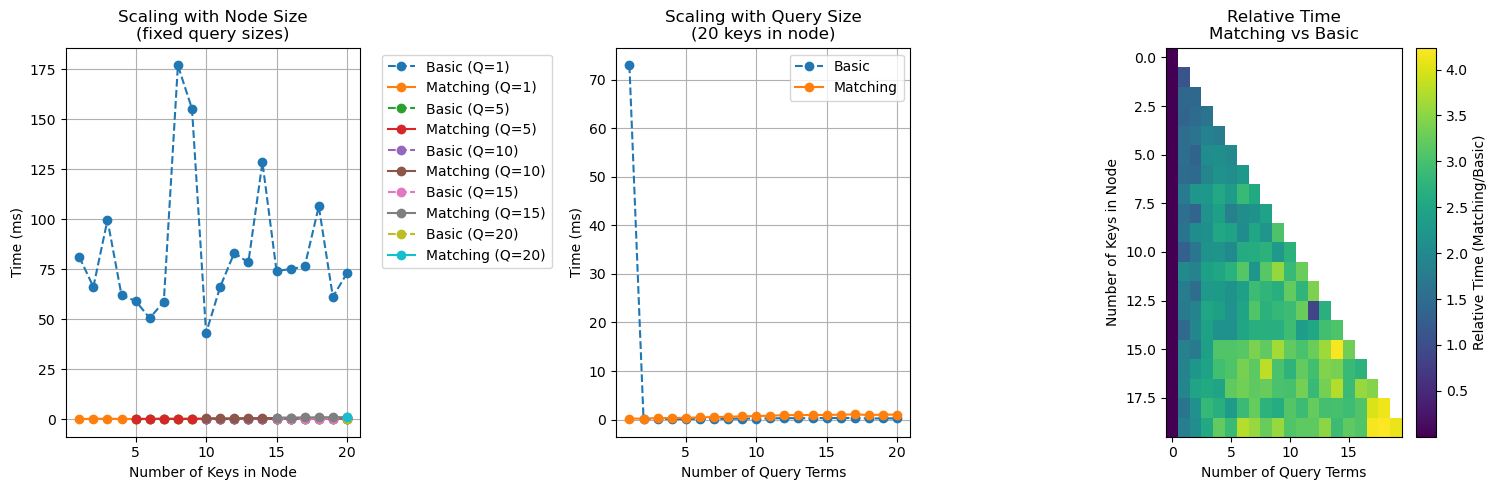


Scaling Summary:

Mean execution times for different node sizes (averaged across query sizes):
           Basic_Time_ms  Matching_Time_ms  Relative_Time
Node_Keys                                                
1                 81.171             0.055          0.001
2                 33.112             0.137          0.547
3                 33.252             0.124          0.953
4                 15.531             0.096          1.130
5                 11.873             0.089          1.355
6                  8.492             0.144          1.511
7                  8.487             0.178          1.627
8                 22.196             0.189          2.064
9                 17.355             0.219          1.788
10                 4.409             0.246          2.065
11                 6.116             0.236          2.027
12                 7.031             0.278          2.475
13                 6.173             0.376          2.321
14                 9.372          

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

def generate_test_data(n_keys):
    """Generate test data with n_keys unique keys"""
    base_keys = [f"key_{i}" for i in range(n_keys)]
    node = MemoryNode(
        content=f"Node with {n_keys} keys",
        keys=base_keys
    )
    node.set_embeddings()
    return node, base_keys

def measure_scaling_times(max_size=20, n_repeats=5):
    sizes = list(range(1, max_size + 1))
    results = []
    
    for size in sizes:
        # Create a node and query of current size
        node, keys = generate_test_data(size)
        
        # Test with different query sizes up to current node size
        for query_size in range(1, size + 1):
            query = keys[:query_size]  # Use subset of keys as query
            
            basic_times = []
            matching_times = []
            
            # Multiple measurements
            for _ in range(n_repeats):
                # Time basic scoring
                t0 = time.perf_counter()
                _ = node.get_score(query, sensitivity=SENS)
                t1 = time.perf_counter()
                basic_times.append(t1 - t0)
                
                # Time matching scoring
                t0 = time.perf_counter()
                _ = node.get_score_matching(query, tau=TAU)
                t1 = time.perf_counter()
                matching_times.append(t1 - t0)
            
            # Calculate statistics
            basic_mean = np.mean(basic_times) * 1000
            matching_mean = np.mean(matching_times) * 1000
            
            results.append({
                'Node_Keys': size,
                'Query_Terms': query_size,
                'Basic_Time_ms': basic_mean,
                'Matching_Time_ms': matching_mean,
                'Relative_Time': matching_mean / basic_mean
            })
    
    return pd.DataFrame(results)

# Run scaling analysis
scaling_df = measure_scaling_times(max_size=20)

# Create visualization
plt.figure(figsize=(15, 5))

# Plot 1: Time vs Node Size (fixed query sizes)
plt.subplot(131)
for q_size in [1, 5, 10, 15, 20]:
    mask = scaling_df['Query_Terms'] == q_size
    if any(mask):
        plt.plot(scaling_df[mask]['Node_Keys'], 
                scaling_df[mask]['Basic_Time_ms'], 
                '--o', label=f'Basic (Q={q_size})')
        plt.plot(scaling_df[mask]['Node_Keys'], 
                scaling_df[mask]['Matching_Time_ms'], 
                '-o', label=f'Matching (Q={q_size})')
plt.xlabel('Number of Keys in Node')
plt.ylabel('Time (ms)')
plt.title('Scaling with Node Size\n(fixed query sizes)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plot 2: Time vs Query Size (for largest node)
plt.subplot(132)
mask = scaling_df['Node_Keys'] == 20
plt.plot(scaling_df[mask]['Query_Terms'], 
         scaling_df[mask]['Basic_Time_ms'], 
         '--o', label='Basic')
plt.plot(scaling_df[mask]['Query_Terms'], 
         scaling_df[mask]['Matching_Time_ms'], 
         '-o', label='Matching')
plt.xlabel('Number of Query Terms')
plt.ylabel('Time (ms)')
plt.title('Scaling with Query Size\n(20 keys in node)')
plt.legend()
plt.grid(True)

# Plot 3: Relative Time Heatmap
plt.subplot(133)
heatmap_data = scaling_df.pivot(index='Node_Keys', 
                               columns='Query_Terms', 
                               values='Relative_Time')
plt.imshow(heatmap_data, aspect='auto', cmap='viridis')
plt.colorbar(label='Relative Time (Matching/Basic)')
plt.xlabel('Number of Query Terms')
plt.ylabel('Number of Keys in Node')
plt.title('Relative Time\nMatching vs Basic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nScaling Summary:")
print("\nMean execution times for different node sizes (averaged across query sizes):")
size_summary = scaling_df.groupby('Node_Keys').agg({
    'Basic_Time_ms': 'mean',
    'Matching_Time_ms': 'mean',
    'Relative_Time': 'mean'
}).round(3)
print(size_summary)

print("\nMean execution times for different query sizes (averaged across node sizes):")
query_summary = scaling_df.groupby('Query_Terms').agg({
    'Basic_Time_ms': 'mean',
    'Matching_Time_ms': 'mean',
    'Relative_Time': 'mean'
}).round(3)
print(query_summary)

# 